### Import libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Implement Eular Maruyama
For a simple Ito SDE  
$dX = b(X)dt + \sigma (X)dW$

We have the following Eular-Maruyama discretisation  
$X_{n+1} = X_n + \epsilon^2 b(X_n) + \epsilon \sigma(X_n)\xi_n$

with $\epsilon = ({\Delta t})^{1/2}$ and $\xi_n \sim N(0,1)$

### Single Particle as SDE

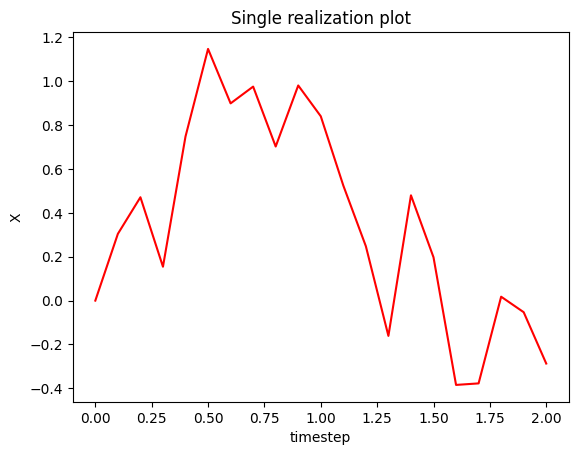

In [146]:
#for a single particle 

#number of steps
n_steps = 20
dt = 0.1
espilon = np.sqrt(dt)

time = np.linspace(0, n_steps*dt, n_steps+1)

sigma  = 1
b = 0

# intial value
X_0 = 0

# solution array with inital value
X = np.zeros(n_steps+1)
X[0] = X_0

#time step
for i in range(n_steps):
    X[i+1] = X[i] +  b* dt + espilon*sigma*np.random.normal(0,1)

# plot one relization
plt.plot(time, X, 'r')
plt.title("Single realization plot")
plt.xlabel("timestep")
plt.ylabel("X")
plt.show()

    

### Single Particle with reflection BC 

Reflection at x=1, new value 0.796 turns to 1.204
Reflection at x=1, new value 0.645 turns to 1.355
Reflection at x=1, new value 0.535 turns to 1.465
Reflection at x=2, new value 2.009 turns to 1.991
Reflection at x=2, new value 2.006 turns to 1.994
Reflection at x=2, new value 2.085 turns to 1.915
Reflection at x=2, new value 2.086 turns to 1.914


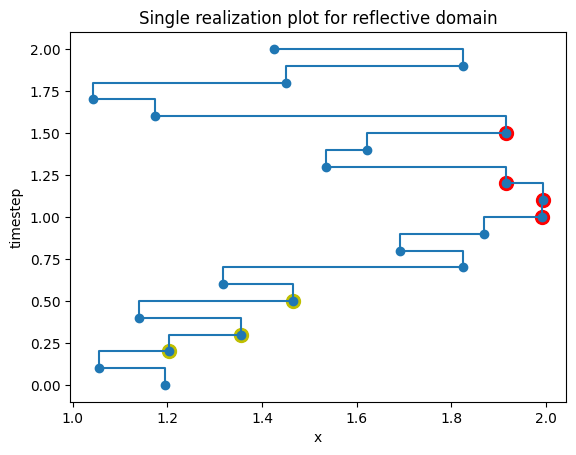

In [143]:
# for a single particel with a boundry (refelction)

#number of steps
n_steps = 20
dt = 0.1
espilon = np.sqrt(dt)

time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries 
bc_1 = 1
bc_2 = 2

#drift and diffusion coefficents
sigma  = 1
b = 0

# intial value
X_0 = np.random.uniform(bc_1,bc_2)

# solution array with inital value
X = np.zeros(n_steps+1)
X[0] = X_0

#keep track of the reflections
reflections = []

#time step
for i in range(n_steps):
    xi = np.random.normal(0,1)
    X[i+1] = X[i] +  b* dt + espilon*sigma* xi
    
    if X[i+1] < bc_1:
        print(f"Reflection at x={bc_1}, new value {X[i+1]:.3f} turns to {2*bc_1-X[i+1]:.3f}")
        X[i+1] = 2*bc_1 - X[i+1]
        reflections.append((X[i+1], (i+1)*dt, "y")) #remember the location of the reflection
    
    if X[i+1] > bc_2:
        print(f"Reflection at x={bc_2}, new value {X[i+1]:.3f} turns to {2*bc_2-X[i+1]:.3f}")
        X[i+1] = 2*bc_2 - X[i+1]
        reflections.append((X[i+1], (i+1)*dt, "r"))


# plot one relization
plt.step(X, time, '-o')

for x, t , c in reflections:
    plt.scatter(x, t, s=100, c=c)

plt.title("Single realization plot for reflective domain")
plt.xlabel("x")
plt.ylabel("timestep")
plt.show()

    

### Single Particle with both reflection and rejection BCs

Reflection at x=0, new value -0.291 turns to 0.291
Rejection at x=0, new value -0.291 stays the same -0.291
Reflection at x=1, new value 1.140 turns to 0.860
Reflection at x=0, new value -0.088 turns to 0.088
Reflection at x=1, new value 1.081 turns to 0.919
Rejection at x=1, new value 1.017 stays the same 0.983
Rejection at x=0, new value -0.165 stays the same -0.165


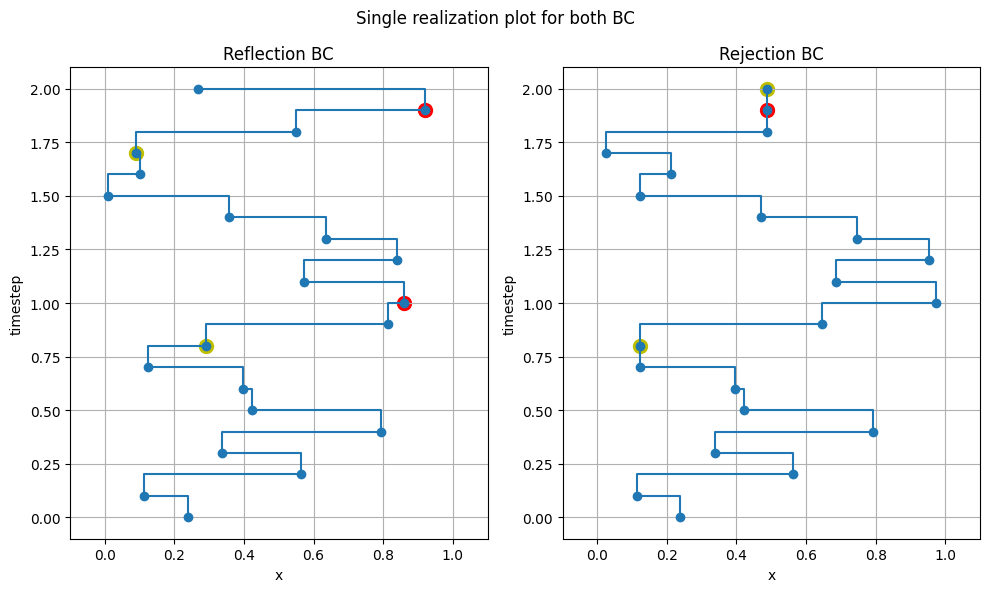

Final x value for reflection is 0.268 and rejection is 0.487


In [141]:
#repeat but for rejection boundry, and compare the two results

#number of steps
n_steps = 20
dt = 0.1
espilon = np.sqrt(dt)

time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries 
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 0

# intial value
X_0 = np.random.uniform(bc_1,bc_2)

# solution array with inital value
X_ref = np.zeros(n_steps+1)
X_rej = np.zeros(n_steps+1)

X_ref[0] = X_0
X_rej[0] = X_0

#keep track of the reflections and rejections
reflections = []
rejections = []


#precompute xi values
xi = np.random.normal(0,1,n_steps)


#time step
for i in range(n_steps):
    X_ref[i+1] = X_ref[i] +  b* dt + espilon*sigma* xi[i]
    
    if X_ref[i+1] < bc_1:
        print(f"Reflection at x={bc_1}, new value {X_ref[i+1]:.3f} turns to {2*bc_1-X_ref[i+1]:.3f}")
        X_ref[i+1] = 2*bc_1 - X_ref[i+1]
        reflections.append((X_ref[i+1], (i+1)*dt, "y")) #remember the location of the reflection
    
    if X_ref[i+1] > bc_2:
        print(f"Reflection at x={bc_2}, new value {X_ref[i+1]:.3f} turns to {2*bc_2-X_ref[i+1]:.3f}")
        X_ref[i+1] = 2*bc_2 - X_ref[i+1]
        reflections.append((X_ref[i+1], (i+1)*dt, "r"))

    
    #do the same but for rejection
    X_rej[i+1] = X_rej[i] +  b* dt + espilon*sigma* xi[i]
    
    if X_rej[i+1] < bc_1:
        print(f"Rejection at x={bc_1}, new value {X_rej[i+1]:.3f} stays the same {X_rej[i+1]:.3f}")
        X_rej[i+1] = X_rej[i]
        rejections.append((X_rej[i+1], (i+1)*dt, "y")) #remember the location of the reflection
    
    if X_rej[i+1] > bc_2:
        print(f"Rejection at x={bc_2}, new value {X_rej[i+1]:.3f} stays the same {2*bc_2-X_rej[i+1]:.3f}")
        X_rej[i+1] = X_rej[i]
        rejections.append((X_rej[i+1], (i+1)*dt, "r"))


# plot one relization
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].step(X_ref, time, '-o')
for x, t , c in reflections:
    ax[0].scatter(x, t, s=100, c=c)

ax[0].set_title("Reflection BC")
ax[0].set_xlabel("x")
ax[0].set_ylabel("timestep")
ax[0].set_xlim(bc_1-0.1, bc_2+0.1)
ax[0].set_ylim(-.1, dt*n_steps+0.1)
ax[0].grid(True)



ax[1].step(X_rej, time, '-o')
for x, t , c in rejections:
    ax[1].scatter(x, t, s=100, c=c)

ax[1].set_title("Rejection BC")
ax[1].set_xlabel("x")
ax[1].set_ylabel("timestep")
ax[1].set_xlim(bc_1-0.1, bc_2+0.1)
ax[1].set_ylim(-.1, dt*n_steps+0.1)
ax[1].grid(True)



fig.suptitle("Single realization plot for both BC")
plt.tight_layout()
plt.show()

print(f"Final x value for reflection is {X_ref[-1]:.3f} and rejection is {X_rej[-1]:.3f}")
    


Intrestingly, the final x values for both boundries always tend to be "not far" from each other

### Multiple Particles as SDE

(21,)


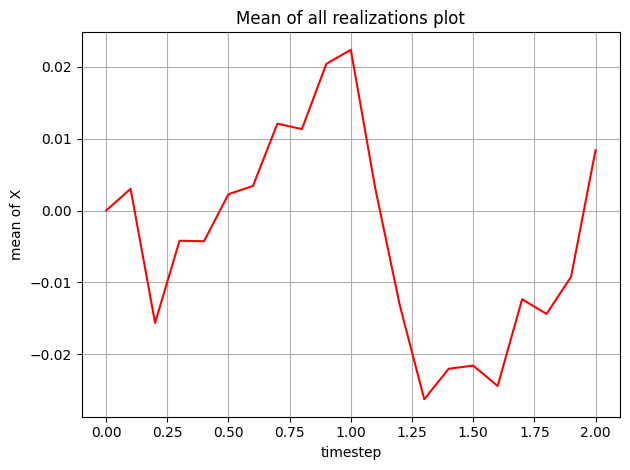

[ 0.          0.00302503 -0.01563754 -0.00420218 -0.00427995  0.00228031
  0.00341954  0.01210404  0.01134056  0.0204308   0.02238123  0.00306997
 -0.01316809 -0.02627031 -0.02202389 -0.02158788 -0.02442026 -0.01235809
 -0.01439045 -0.00922733  0.00840294]
[0.         0.10308021 0.20460047 0.29918146 0.40402377 0.51059289
 0.61945741 0.71627451 0.817862   0.90928255 1.01164298 1.07404976
 1.17859848 1.27892791 1.3692651  1.45064289 1.55658591 1.6913703
 1.82199167 1.93225397 2.07402119]


In [148]:
#experiment for multiple particle 

n_parts = 1000

#number of steps
n_steps = 20
dt = 0.1
espilon = np.sqrt(dt)

time = np.linspace(0, n_steps*dt, n_steps+1)

sigma  = 1
b = 0

# solution array with inital value (0 for this case)
X = np.zeros((n_steps+1, n_parts))


#time step
for i in range(n_steps):
    X[i+1,:] = X[i,:] +  b*dt + espilon*sigma*np.random.normal(0,1,n_parts)


# plot the mean and varaince
X_mean = np.mean(X, axis=1)
X_var = np.var(X, axis=1)
X_std = np.sqrt(X_var)

print(X_mean.shape)

plt.plot(time, X_mean, 'r')
# plt.fill_between(time, X_mean+X_std, X_mean-X_std)
plt.title("Mean of all realizations plot")
plt.xlabel("timestep")
plt.ylabel("mean of X")
plt.grid(True)
plt.tight_layout()
plt.show()

print(X_mean)
print(X_var)
    

### Multiple particles in a bounded domain, both BCs

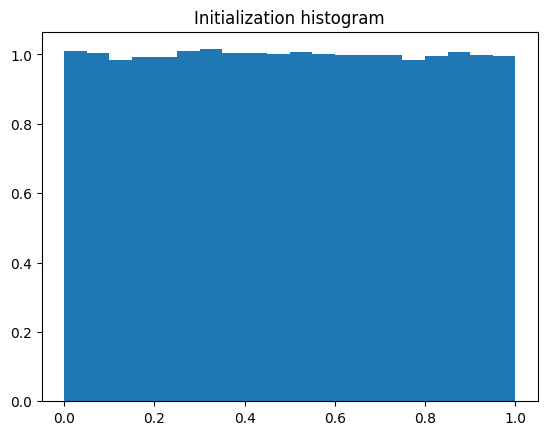

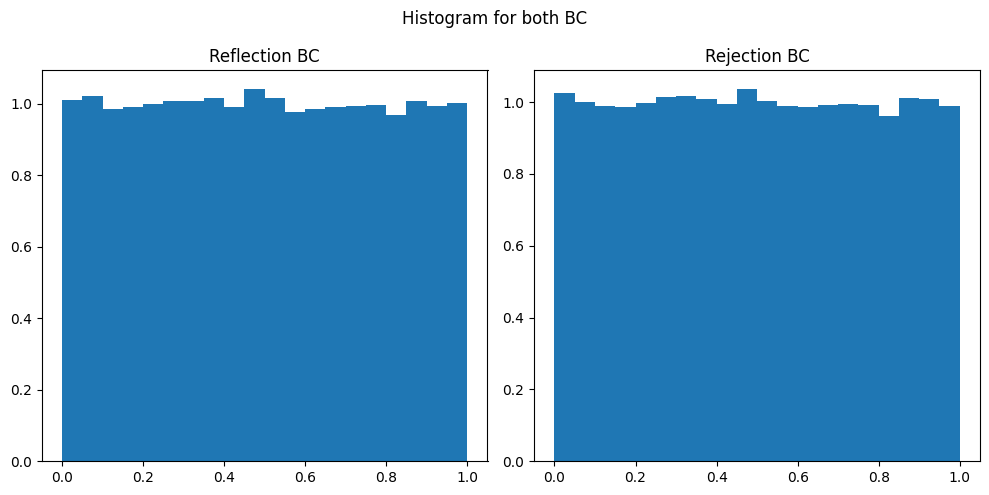

In [20]:

n_parts = 100000

#number of steps
n_steps = 200
dt = 0.001
espilon = np.sqrt(dt)

time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries 
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 0

# intial value
X_0 = np.random.uniform(bc_1,bc_2, n_parts)

# solution array with inital value
X_ref = np.zeros((n_steps+1, n_parts))
X_rej = np.zeros((n_steps+1, n_parts))

X_ref[0,:] = X_0
X_rej[0,:] = X_0

plt.hist(X_0, bins=20, density=True)
plt.title("Initialization histogram")
plt.show()

#keep track of the reflections and rejections
reflections = []
rejections = []


#precompute xi values
xi = np.random.normal(0,1, (n_steps,n_parts))

# this was just test for uniform instead of normal, same result as the theory
# xi = np.random.uniform(-1,1, (n_steps,n_parts)) 


# fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#time step
for i in range(n_steps):
    X_ref[i+1,:] = X_ref[i,:] +  b* dt + espilon*sigma* xi[i, :]
    
    #left boundry first then the right boundry
    X_ref[i+1, X_ref[i+1, :] < bc_1] = 2*bc_1 - X_ref[i+1, X_ref[i+1, :] < bc_1]
    X_ref[i+1, X_ref[i+1, :] > bc_2] = 2*bc_2 - X_ref[i+1, X_ref[i+1, :] > bc_2]

    
    #do the same but for rejection
    X_rej[i+1,:] = X_rej[i,:] +  b* dt + espilon*sigma* xi[i, :]

    X_rej[i+1, X_rej[i+1, :] < bc_1] = X_rej[i, X_rej[i+1, :] < bc_1]
    X_rej[i+1, X_rej[i+1, :] > bc_2] = X_rej[i, X_rej[i+1, :] > bc_2]

    #this is taken from the code provided by SV
    #not working with subplots, need fixing later
    # if ((i+1) % 50 == 0):
    #     ax[0].cla()
    #     ax[1].cla()

    #     ax[0].set_title("Reflection BC")
    #     ax[0].hist(X_ref[i+1,:], bins=20, density=True)

    #     ax[1].set_title("Rejection BC")
    #     ax[1].hist(X_rej[i+1, :], bins=20, density=True)

    #     fig.suptitle(f"histogram change at {i}")
    #     plt.pause(1)

    

# plot relization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


ax[0].set_title("Reflection BC")
ax[0].hist(X_ref[-1,:], bins=20, density=True)

ax[1].set_title("Rejection BC")
ax[1].hist(X_rej[-1, :], bins=20, density=True)


fig.suptitle("Histogram for both BC")
plt.tight_layout()
plt.show()

    


### same as above diffrent initilaiztion

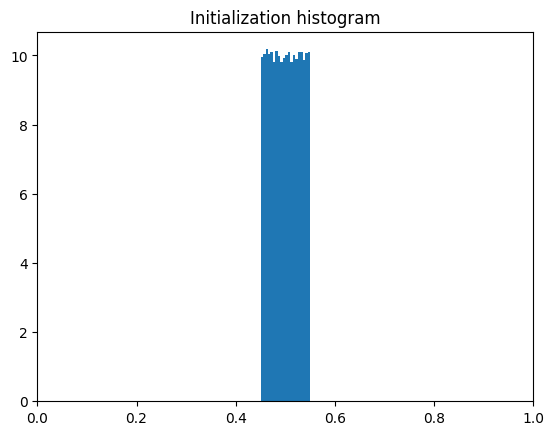

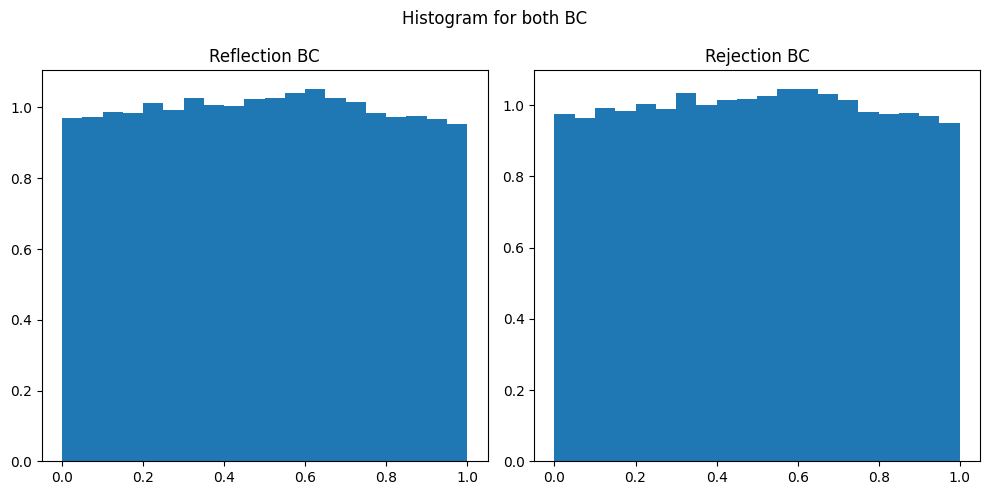

In [25]:

n_parts = 100000

#number of steps
n_steps = 200
dt = 0.001
espilon = np.sqrt(dt)

time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries 
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 0

# intial value
X_0 = np.random.uniform(.45,.55, n_parts)

# solution array with inital value
X_ref = np.zeros((n_steps+1, n_parts))
X_rej = np.zeros((n_steps+1, n_parts))

X_ref[0,:] = X_0
X_rej[0,:] = X_0

plt.hist(X_0, bins=20, density=True)
plt.title("Initialization histogram")
plt.xlim((bc_1, bc_2))
plt.show()

#keep track of the reflections and rejections
reflections = []
rejections = []


#precompute xi values
xi = np.random.normal(0,1, (n_steps,n_parts))

# this was just test for uniform instead of normal, same result as the theory
# xi = np.random.uniform(-1,1, (n_steps,n_parts)) 


# fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#time step
for i in range(n_steps):
    X_ref[i+1,:] = X_ref[i,:] +  b* dt + espilon*sigma* xi[i, :]
    
    #left boundry first then the right boundry
    X_ref[i+1, X_ref[i+1, :] < bc_1] = 2*bc_1 - X_ref[i+1, X_ref[i+1, :] < bc_1]
    X_ref[i+1, X_ref[i+1, :] > bc_2] = 2*bc_2 - X_ref[i+1, X_ref[i+1, :] > bc_2]

    
    #do the same but for rejection
    X_rej[i+1,:] = X_rej[i,:] +  b* dt + espilon*sigma* xi[i, :]

    X_rej[i+1, X_rej[i+1, :] < bc_1] = X_rej[i, X_rej[i+1, :] < bc_1]
    X_rej[i+1, X_rej[i+1, :] > bc_2] = X_rej[i, X_rej[i+1, :] > bc_2]

    #this is taken from the code provided by SV
    #not working with subplots, need fixing later
    # if ((i+1) % 50 == 0):
    #     ax[0].cla()
    #     ax[1].cla()

    #     ax[0].set_title("Reflection BC")
    #     ax[0].hist(X_ref[i+1,:], bins=20, density=True)

    #     ax[1].set_title("Rejection BC")
    #     ax[1].hist(X_rej[i+1, :], bins=20, density=True)

    #     fig.suptitle(f"histogram change at {i}")
    #     plt.pause(1)

    

# plot relization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


ax[0].set_title("Reflection BC")
ax[0].hist(X_ref[-1,:], bins=20, density=True)

ax[1].set_title("Rejection BC")
ax[1].hist(X_rej[-1, :], bins=20, density=True)


fig.suptitle("Histogram for both BC")
plt.tight_layout()
plt.show()

    
